In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
os.chdir('..')

In [3]:
indicators = pd.read_csv('data/indicators.csv')

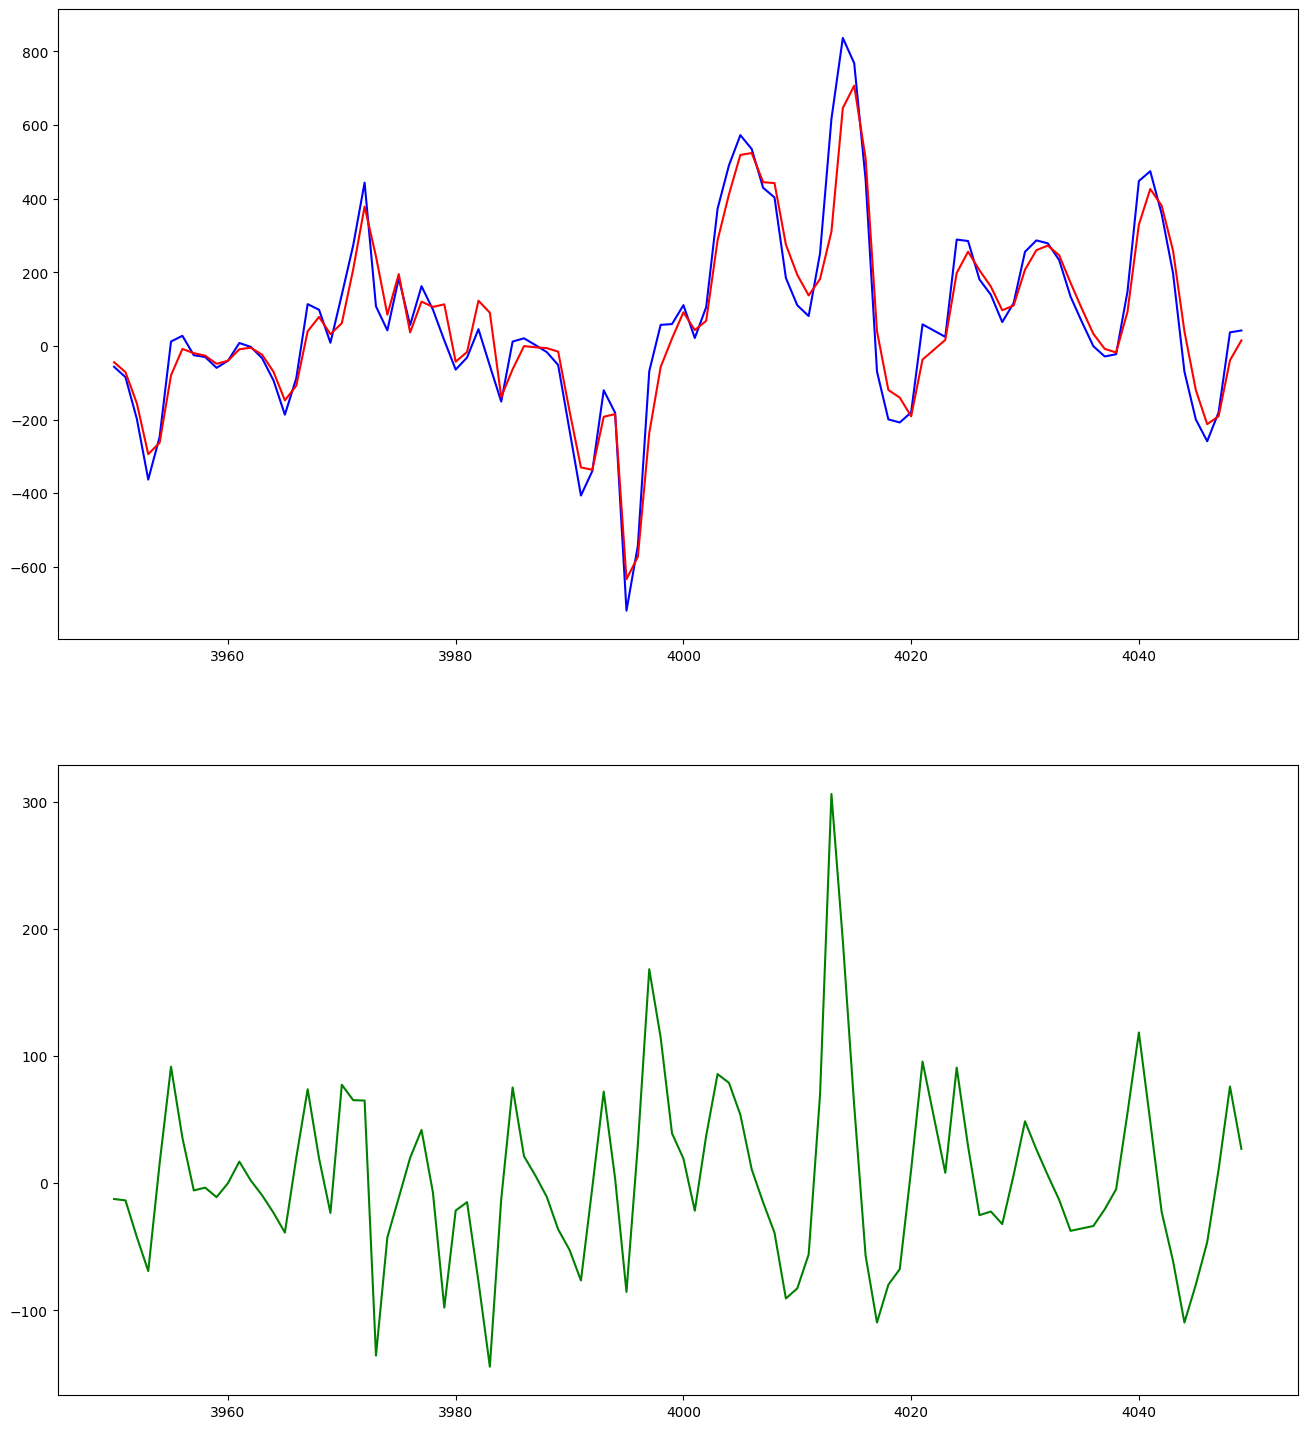

In [4]:
macd_close_28 = indicators['fe_macd_opt_close_28']
signal_close_28 = indicators['fe_macd_signal_opt_close_28']
hist_close_28 = macd_close_28 - signal_close_28

fig, axes = plt.subplots(2,1 , figsize=(16,18))

axes[0].plot(macd_close_28[-100:], color='blue', label='MACD_28')
axes[0].plot(signal_close_28[-100:], color='red', label='Signal_28')
axes[1].plot(hist_close_28[-100:], color='green', label='Histogram')

In [5]:
trade_df = pd.DataFrame({'close':indicators['close'], 'open':indicators['open']})
trade_df = trade_df.astype({
    'close': np.int32,
    'open': np.int32
})

In [6]:
trade_df['tomorrows_returns'] = 0
trade_df['tomorrows_returns'] = trade_df['close'] - trade_df['close'].shift(1)
trade_df['tomorrows_returns'] = trade_df['tomorrows_returns'].shift(-1)
trade_df.head()

,close,open,tomorrows_returns
0,71163,71156,-322.0
1,70841,71163,25.0
2,70866,70843,74.0
3,70940,70866,55.0
4,70995,70940,97.0


In [7]:
trade_df['close'].shift(1)

0           NaN
1       71163.0
2       70841.0
3       70866.0
4       70940.0
         ...   
4045    70190.0
4046    68955.0
4047    69405.0
4048    69129.0
4049    69548.0
Name: close, Length: 4050, dtype: float64

In [8]:
trade_df.loc[:, 'cumulative_market_return'] = np.cumsum(trade_df['tomorrows_returns'])

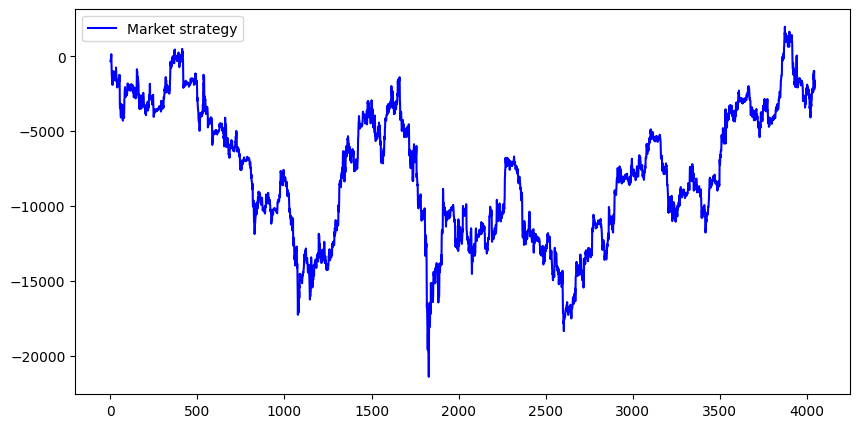

In [9]:
fig, ax =plt.subplots(1,1, figsize=(10,5))
ax.plot(trade_df['cumulative_market_return'], color='blue', label='Market strategy')
ax.legend()
plt.show()

# MACD Strategy

In [10]:
trade_df.loc[:,'macd_close_28'] = macd_close_28
trade_df.loc[:,'signal_close_28'] = signal_close_28

In [11]:
from strategy.functions import *
trade_df = macd_crossover_strategy(trade_df, macd_col='macd_close_28', signal_col='signal_close_28')

In [12]:
trade_df[-15:]

,close,open,tomorrows_returns,cumulative_market_return,macd_close_28,signal_close_28,signals
4035,68744,69002,-12.0,-2431.0,64.779223,100.331276,0
4036,68732,68744,47.0,-2384.0,-0.732466,32.955448,0
4037,68779,68732,53.0,-2331.0,-28.639480,-8.107837,0
4038,68832,68779,-45.0,-2376.0,-22.583688,-17.758404,0
4039,68787,68832,1154.0,-1222.0,147.849787,92.647057,1
4040,69941,68787,-341.0,-1563.0,448.109872,329.622267,0
4041,69600,69940,555.0,-1008.0,474.665923,426.318038,0
4042,70155,69600,-236.0,-1244.0,358.599554,381.172382,-1
4043,69919,70155,271.0,-973.0,197.759732,258.897282,0
4044,70190,69920,-1235.0,-2208.0,-69.744161,39.802987,0


In [13]:
# trade_idx = np.where(trade_df['signals'] !=0)[0]
strategy_returns = np.zeros((len(trade_df),1), dtype=np.int32)

trade_df.loc[:,'strategy_returns'] = strategy_returns

holding_position = False


for i in range(len(trade_df)):

    if trade_df.loc[i, 'signals'] ==1 and not holding_position:
        holding_position = True
        buy_index = i

    elif trade_df.loc[i, 'signals'] == -1 and holding_position:
        holding_position = False

        trade_df.loc[buy_index:i-1, 'strategy_returns'] = trade_df.loc[buy_index:i-1, 'tomorrows_returns']

    elif i == len(trade_df) - 1 and holding_position:
        holding_position = False

        trade_df.loc[buy_index:i-1, 'strategy_returns'] = trade_df.loc[buy_index:i-1, 'tomorrows_returns']
    

In [14]:
trade_df

,close,open,tomorrows_returns,cumulative_market_return,macd_close_28,signal_close_28,signals,strategy_returns
0,71163,71156,-322.0,-322.0,99.920341,82.464144,0,0
1,70841,71163,25.0,-297.0,80.931659,67.171907,0,0
2,70866,70843,74.0,-223.0,-62.365727,-18.710761,0,0
3,70940,70866,55.0,-168.0,-370.049108,-253.066592,0,0
4,70995,70940,97.0,-71.0,-57.059902,-82.558760,1,97
...,...,...,...,...,...,...,...,...
4045,68955,70201,450.0,-1758.0,-199.646496,-119.830002,0,0
4046,69405,68961,-276.0,-2034.0,-258.987898,-212.601932,0,0
4047,69129,69407,419.0,-1615.0,-180.592739,-191.262470,1,419
4048,69548,69126,-205.0,-1820.0,36.844357,-39.191252,0,-205


In [15]:
trade_df.loc[:, 'cumulative_macd_return'] = trade_df['strategy_returns'].cumsum()

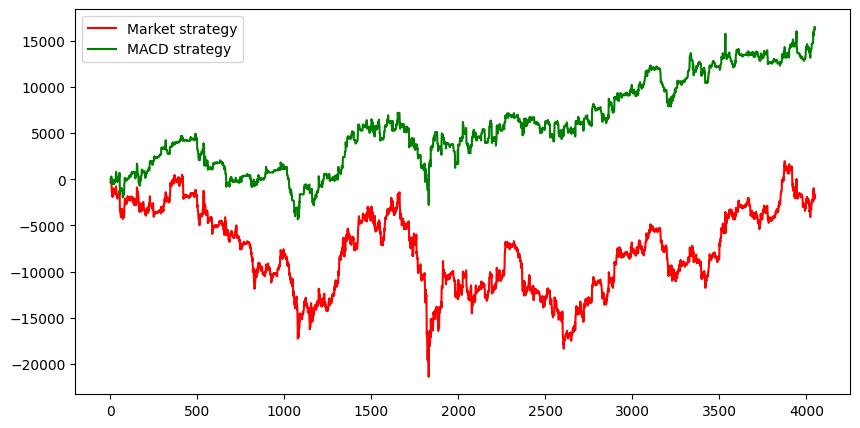

In [16]:
fig, ax =plt.subplots(1,1, figsize=(10,5))
ax.plot(trade_df['cumulative_market_return'], color='red', label='Market strategy')
ax.plot(trade_df['cumulative_macd_return'], color = 'green', label = 'MACD strategy')
ax.legend()
plt.show()

# MACD xLSTM strategy

In [17]:
y_train_xlstm = np.load('xgboost/train_predictions.npy')[:,-1,:].reshape(-1,1)
y_val_xlstm = np.load('xgboost/val_predictions.npy')[:,-1,:].reshape(-1,1)
y_test_xlstm = np.load('xgboost/test_predictions.npy')[:,-1,:].reshape(-1,1)


In [18]:
y_xlstm = np.vstack((y_train_xlstm, y_val_xlstm, y_test_xlstm)).reshape(-1)


In [19]:
y_xlstm.shape

(4024,)

In [20]:
trade_df_new = trade_df[-4024:].copy()

In [21]:
y_xlstm

array([69480.14 , 69888.17 , 69802.24 , ..., 69029.984, 69171.35 ,
       69451.25 ], dtype=float32)

In [22]:
y_xlstm = np.roll(y_xlstm, -1)
y_xlstm

array([69888.17, 69802.24, 69705.63, ..., 69171.35, 69451.25, 69480.14],
      dtype=float32)

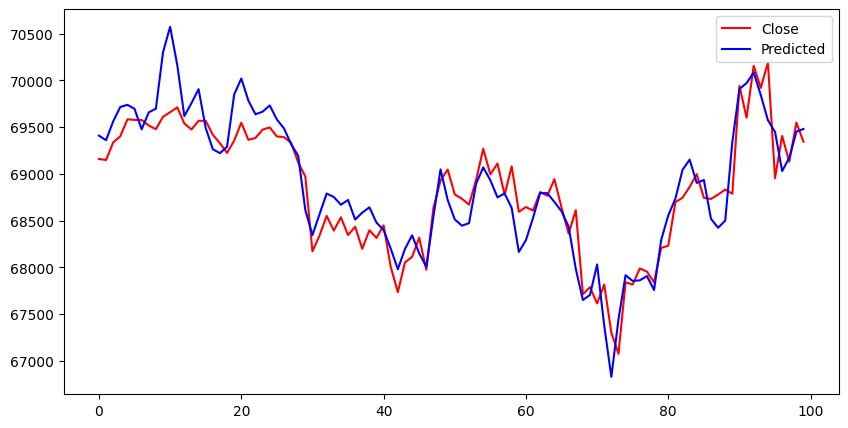

In [23]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.plot(trade_df['close'][-100:].to_numpy(), color='red', label='Close')
ax.plot(y_xlstm[-100:], color='blue', label='Predicted')
plt.legend()


In [24]:
trade_df_new.loc[:,'y_xlstm'] = y_xlstm

In [25]:
trade_df_new = trade_df_new.reset_index(drop=True)

In [26]:
import numpy as np
import pandas as pd

def macd_xlstm_strategy(df, macd_col='macd_close_28', signal_col='signal_close_28'):
    """
    Implements a MACD-XLSTM trading strategy with additional conditions.

    Parameters:
        df (pd.DataFrame): Input DataFrame containing MACD, Signal, y_xlstm, and close columns.
        macd_col (str): Name of the MACD column (default: 'macd_close_28').
        signal_col (str): Name of the Signal column (default: 'signal_close_28').

    Returns:
        pd.DataFrame: DataFrame with an additional 'signals_macd_xlstm' column indicating Buy (1), Sell (-1), or Hold (0).
    """
    # Generate Buy/Sell signals with additional conditions
    buy_signals = (df[macd_col] > df[signal_col]) & (df[macd_col].shift(1) <= df[signal_col].shift(1)) & (df['y_xlstm'] > df['close'])
    sell_signals = (df[macd_col] < df[signal_col]) & (df[macd_col].shift(1) >= df[signal_col].shift(1)) & (df['y_xlstm'] < df['close'])

    # Initialize signals array with zeros (Hold)
    signals = np.zeros(len(df), dtype=np.int8)

    # Track whether we are currently holding a position
    holding_position = False

    # Iterate through the DataFrame to assign signals
    for i in range(len(df)):
        if buy_signals[i] and not holding_position:
            # Buy signal: Open a position
            signals[i] = 1
            holding_position = True
        elif sell_signals[i] and holding_position:
            # Sell signal: Close the position
            signals[i] = -1
            holding_position = False

    # Ensure the first trade is a Buy (if any)
    trade_idx = np.where(signals != 0)[0]
    if len(trade_idx) > 0 and signals[trade_idx[0]] == -1:
        signals[trade_idx[0]] = 0  # Remove the first Sell signal

    # If the last signal is a Buy, close the position at the end
    if len(trade_idx) > 0 and signals[trade_idx[-1]] == 1:
        signals[-1] = -1  # Close the position at the end

    # Add signals to the DataFrame
    df.loc[:, 'signals_macd_xlstm'] = signals
    return df

trade_df_new = macd_xlstm_strategy(trade_df_new)

In [27]:
trade_df_new = trade_df_new.reset_index(drop=True)

In [28]:
# trade_idx = np.where(trade_df['signals'] !=0)[0]
strategy_returns = np.zeros((len(trade_df_new),1), dtype=np.int32)

trade_df_new.loc[:,'xlstm_strategy_returns'] = strategy_returns

holding_position = False


for i in range(len(trade_df_new)):

    if trade_df_new.loc[i, 'signals_macd_xlstm'] ==1 and not holding_position:
        holding_position = True
        buy_index = i
        
    elif trade_df_new.loc[i, 'signals_macd_xlstm'] == -1 and holding_position:
        holding_position = False

        trade_df_new.loc[buy_index:i-1, 'xlstm_strategy_returns'] = trade_df_new.loc[buy_index:i-1, 'tomorrows_returns']

    elif i == len(trade_df_new) - 1 and holding_position:
        holding_position = False

        trade_df_new.loc[buy_index:i-1, 'xlstm_strategy_returns'] = trade_df_new.loc[buy_index:i-1, 'tomorrows_returns']
    

In [29]:
trade_df_new.loc[:, 'cumulative_xlstm_return'] = trade_df_new['xlstm_strategy_returns'].cumsum()

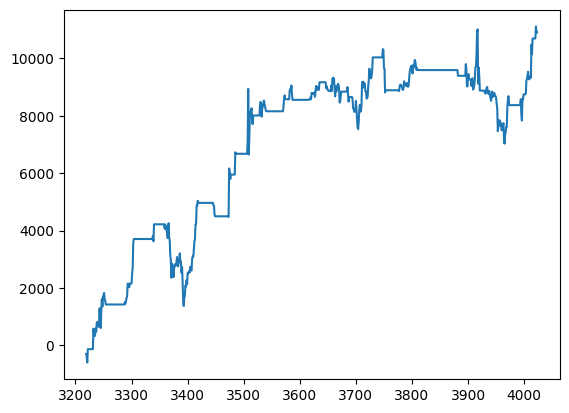

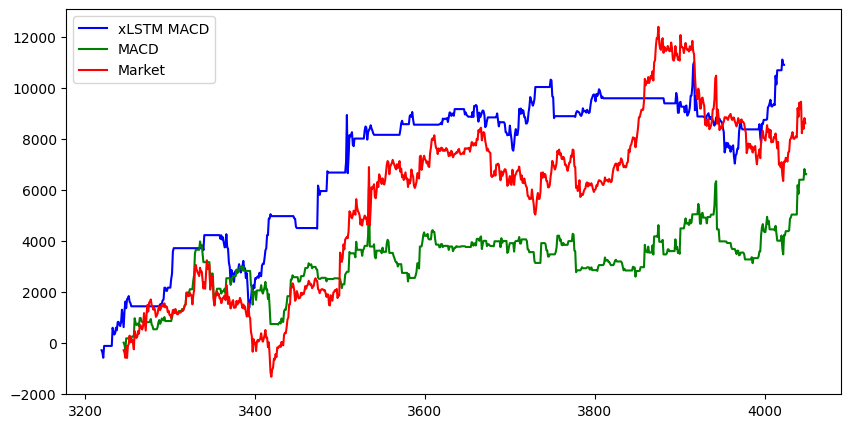

In [30]:
plt.plot(trade_df_new['xlstm_strategy_returns'][-805:].cumsum())

fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.plot(trade_df_new['xlstm_strategy_returns'][-805:].cumsum(), color='blue', label = "xLSTM MACD")
ax.plot(trade_df['strategy_returns'][-805:].cumsum(), color='green', label='MACD')
ax.plot(trade_df['tomorrows_returns'][-805:].cumsum(), color='red', label = 'Market')
plt.legend()


In [31]:
x

NameError: name 'x' is not defined

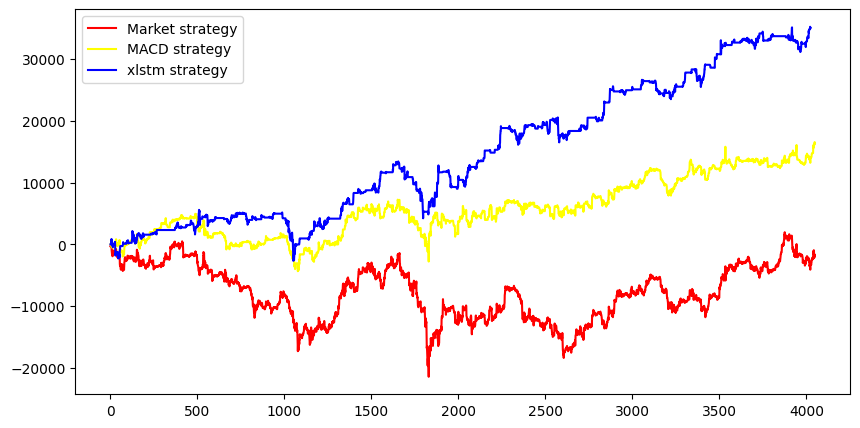

In [35]:
fig, ax =plt.subplots(1,1, figsize=(10,5))
ax.plot(trade_df['cumulative_market_return'], color='red', label='Market strategy')
ax.plot(trade_df['cumulative_macd_return'], color = 'yellow', label = 'MACD strategy')
ax.plot(trade_df_new['cumulative_xlstm_return'], color = 'blue', label = 'xlstm strategy')

ax.legend()
plt.show()

In [33]:
trade_df_new['xlstm_strategy_returns'][1004:1030]

1004       0
1005       0
1006       0
1007    -376
1008      82
1009    -202
1010       7
1011    -374
1012     562
1013    -250
1014    -128
1015     305
1016    -125
1017    -133
1018    -535
1019     -76
1020     631
1021      67
1022    -110
1023     215
1024   -1812
1025     395
1026     140
1027    -159
1028     -58
1029    -101
Name: xlstm_strategy_returns, dtype: int32

In [34]:
trade_df_new['close'][1004:1030]

1004    60751
1005    61001
1006    60919
1007    60776
1008    60400
1009    60482
1010    60280
1011    60287
1012    59913
1013    60475
1014    60225
1015    60097
1016    60402
1017    60277
1018    60144
1019    59609
1020    59533
1021    60164
1022    60231
1023    60121
1024    60336
1025    58524
1026    58919
1027    59059
1028    58900
1029    58842
Name: close, dtype: int32